# IN5437 — Assignment 1
## Question 1: Intensity Transformations on the Runway Image

**Name:** Benjamine  
**Index:** 258762Q

Three intensity transformations applied to the runway image:
- (a) Gamma correction with γ = 0.5
- (b) Gamma correction with γ = 2.0
- (c) Piecewise-linear contrast stretching with r₁ = 0.2, r₂ = 0.8

Each is implemented using a lookup table (LUT), following the L02 methodology.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read the runway image in grayscale (relative path from notebooks/ to images/)
q1_im = cv.imread('../images/runway.png', cv.IMREAD_GRAYSCALE)
assert q1_im is not None, "File could not be read. Check the path."
print('Shape:', q1_im.shape, '| Min:', q1_im.min(), '| Max:', q1_im.max(), '| Mean:', round(float(q1_im.mean()), 2))

Shape: (769, 765) | Min: 0 | Max: 255 | Mean: 197.12


### Question 01.a: Gamma correction, γ = 0.5

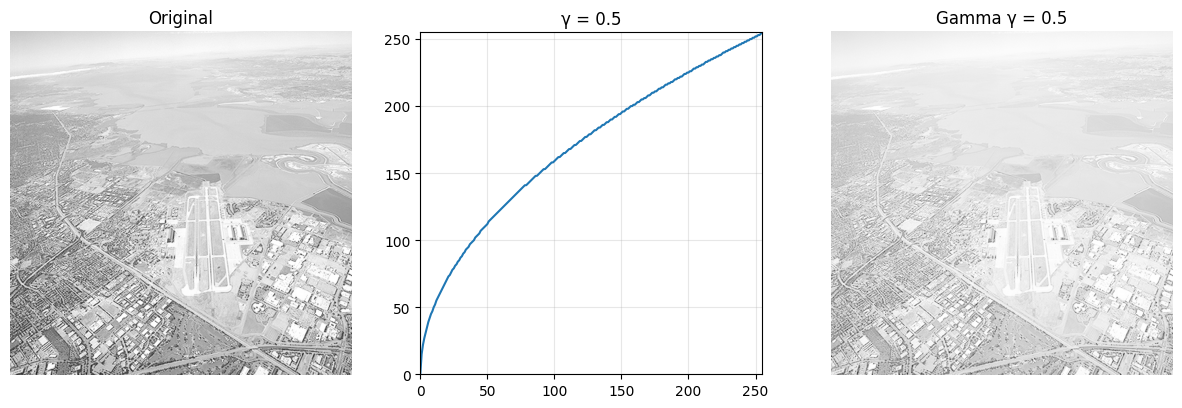

In [3]:
# Build LUT for γ = 0.5
gamma_1a = 0.5
t_1a = np.array([((i/255.0) ** gamma_1a) * 255 for i in np.arange(0, 256)]).astype(np.uint8)

# Apply the LUT
g_1a = cv.LUT(q1_im, t_1a)

# Display: original | curve | result
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(q1_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].plot(np.arange(256), t_1a); ax[1].set_xlim(0,255); ax[1].set_ylim(0,255); ax[1].set_title(f'γ = {gamma_1a}'); ax[1].grid(alpha=0.3); ax[1].set_aspect('equal')
ax[2].imshow(g_1a, cmap='gray', vmin=0, vmax=255); ax[2].set_title(f'Gamma γ = {gamma_1a}'); ax[2].axis('off')
plt.show()

### Question 01.b: Gamma correction, γ = 2

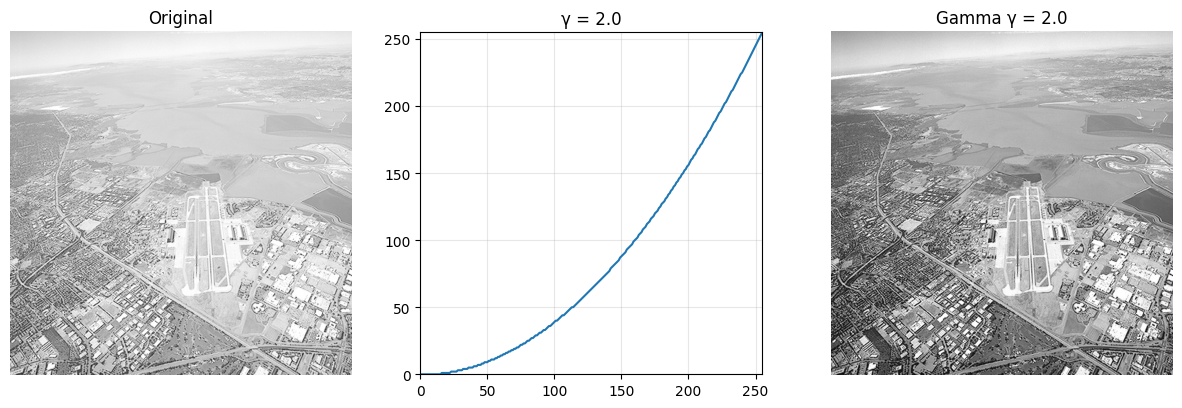

In [4]:
# Build LUT for γ = 2.0
gamma_1b = 2.0
t_1b = np.array([((i/255.0) ** gamma_1b) * 255 for i in np.arange(0, 256)]).astype(np.uint8)

# Apply the LUT
g_1b = cv.LUT(q1_im, t_1b)

# Display
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(q1_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].plot(np.arange(256), t_1b); ax[1].set_xlim(0,255); ax[1].set_ylim(0,255); ax[1].set_title(f'γ = {gamma_1b}'); ax[1].grid(alpha=0.3); ax[1].set_aspect('equal')
ax[2].imshow(g_1b, cmap='gray', vmin=0, vmax=255); ax[2].set_title(f'Gamma γ = {gamma_1b}'); ax[2].axis('off')
plt.show()

### Question 01.c: Contrast stretching, r₁ = 0.2, r₂ = 0.8

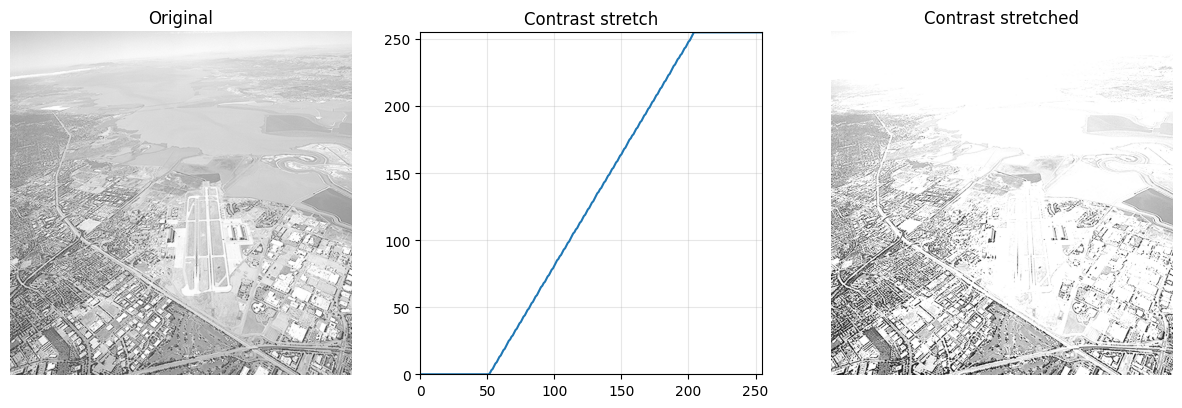

In [5]:
# Build the piecewise LUT
r1_1c, r2_1c = 0.2, 0.8
r_norm = np.arange(256) / 255.0
s_norm = np.zeros_like(r_norm)
mid = (r_norm >= r1_1c) & (r_norm <= r2_1c)
s_norm[mid] = (r_norm[mid] - r1_1c) / (r2_1c - r1_1c)
s_norm[r_norm > r2_1c] = 1.0
t_1c = np.clip(s_norm * 255, 0, 255).astype(np.uint8)

# Apply the LUT
g_1c = cv.LUT(q1_im, t_1c)

# Display
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(q1_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].plot(np.arange(256), t_1c); ax[1].set_xlim(0,255); ax[1].set_ylim(0,255); ax[1].set_title('Contrast stretch'); ax[1].grid(alpha=0.3); ax[1].set_aspect('equal')
ax[2].imshow(g_1c, cmap='gray', vmin=0, vmax=255); ax[2].set_title('Contrast stretched'); ax[2].axis('off')
plt.show()